# Case Study 9: VAE — Latent Space Visualization
**Objective:** Build a VAE on MNIST with a focus on latent space structure and visualization.
**Covers:** VAE architecture, KL + reconstruction loss, latent space separation, interpretation of latent variables.

In [1]:
!pip install torch torchvision matplotlib numpy scikit-learn --quiet

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torchvision.utils import make_grid
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## 1. Load MNIST

In [3]:
transform    = transforms.Compose([transforms.ToTensor()])
train_ds     = datasets.MNIST('.', train=True,  download=True, transform=transform)
test_ds      = datasets.MNIST('.', train=False, download=True, transform=transform)
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=128, shuffle=False)
print(f'Train: {len(train_ds)}, Test: {len(test_ds)}')

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 485kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.46MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.21MB/s]


Train: 60000, Test: 10000


## 2. VAE Architecture

In [4]:
class VAEEncoder(nn.Module):
    """Encodes input x into mu and log_var of q(z|x)."""
    def __init__(self, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512), nn.ReLU(),
            nn.Linear(512, 256), nn.ReLU()
        )
        self.fc_mu      = nn.Linear(256, latent_dim)
        self.fc_log_var = nn.Linear(256, latent_dim)

    def forward(self, x):
        h = self.net(x)
        return self.fc_mu(h), self.fc_log_var(h)

class VAEDecoder(nn.Module):
    """Decodes latent z back into image space."""
    def __init__(self, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256), nn.ReLU(),
            nn.Linear(256, 512),        nn.ReLU(),
            nn.Linear(512, 784),        nn.Sigmoid()
        )
    def forward(self, z):
        return self.net(z).view(-1, 1, 28, 28)

class VAE(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()
        self.encoder = VAEEncoder(latent_dim)
        self.decoder = VAEDecoder(latent_dim)
        self.latent_dim = latent_dim

    def reparameterize(self, mu, log_var):
        """Reparameterization trick: z = mu + eps*std, eps~N(0,1)."""
        if self.training:
            std = torch.exp(0.5 * log_var)
            eps = torch.randn_like(std)
            return mu + eps * std
        return mu  # at inference, use mean

    def forward(self, x):
        mu, log_var = self.encoder(x)
        z     = self.reparameterize(mu, log_var)
        recon = self.decoder(z)
        return recon, mu, log_var

    def sample(self, n, device):
        z = torch.randn(n, self.latent_dim).to(device)
        return self.decoder(z)

# Train two versions: 2D latent (visualizable) and 16D (higher quality)
vae2d  = VAE(latent_dim=2).to(device)
print(f'VAE (2D latent)  params: {sum(p.numel() for p in vae2d.parameters()):,}')
print()
print('Architecture summary:')
print('  Input → Encoder → μ, σ² (2D) → Reparameterize → z → Decoder → Reconstruction')

VAE (2D latent)  params: 1,068,820

Architecture summary:
  Input → Encoder → μ, σ² (2D) → Reparameterize → z → Decoder → Reconstruction


## 3. Loss Function (KL + Reconstruction)

In [5]:
def vae_loss(recon, x, mu, log_var, beta=1.0):
    """
    ELBO Loss = Reconstruction Loss + beta * KL Divergence

    Reconstruction: how accurately we rebuild the input
        = Binary cross entropy pixel-wise

    KL Divergence: how close q(z|x) is to prior p(z) = N(0,1)
        = -0.5 * sum(1 + log_var - mu^2 - exp(log_var))

    beta > 1 → stronger regularization → more disentangled latent space
    beta = 1 → standard VAE
    """
    recon_loss = F.binary_cross_entropy(recon, x, reduction='sum')
    kl_loss    = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    return recon_loss + beta * kl_loss, recon_loss.item(), kl_loss.item()

print('Loss function defined.')
print('  Reconstruction loss: Binary cross-entropy (pixel-level)')
print('  KL divergence:       KL(q(z|x) || N(0,1))')
print('  Total ELBO:          Recon + beta * KL')

Loss function defined.
  Reconstruction loss: Binary cross-entropy (pixel-level)
  KL divergence:       KL(q(z|x) || N(0,1))
  Total ELBO:          Recon + beta * KL


## 4. Training

In [6]:
EPOCHS   = 30
BETA     = 1.0
optimizer = optim.Adam(vae2d.parameters(), lr=1e-3)

history = {'total': [], 'recon': [], 'kl': []}

for epoch in range(EPOCHS):
    vae2d.train()
    t_total = t_recon = t_kl = 0
    for imgs, _ in train_loader:
        imgs = imgs.to(device)
        optimizer.zero_grad()
        recon, mu, log_var = vae2d(imgs)
        loss, rl, kl = vae_loss(recon, imgs, mu, log_var, BETA)
        loss.backward()
        optimizer.step()
        N = imgs.size(0)
        t_total += loss.item()/N; t_recon += rl/N; t_kl += kl/N
    history['total'].append(t_total / len(train_loader))
    history['recon'].append(t_recon / len(train_loader))
    history['kl'].append(t_kl    / len(train_loader))
    if (epoch+1) % 10 == 0:
        print(f'Epoch {epoch+1}/{EPOCHS} | Total: {history["total"][-1]:.2f} | Recon: {history["recon"][-1]:.2f} | KL: {history["kl"][-1]:.2f}')

Epoch 10/30 | Total: 142.87 | Recon: 136.41 | KL: 6.46
Epoch 20/30 | Total: 138.66 | Recon: 131.92 | KL: 6.74
Epoch 30/30 | Total: 136.48 | Recon: 129.58 | KL: 6.91


## 5. Latent Space Separation

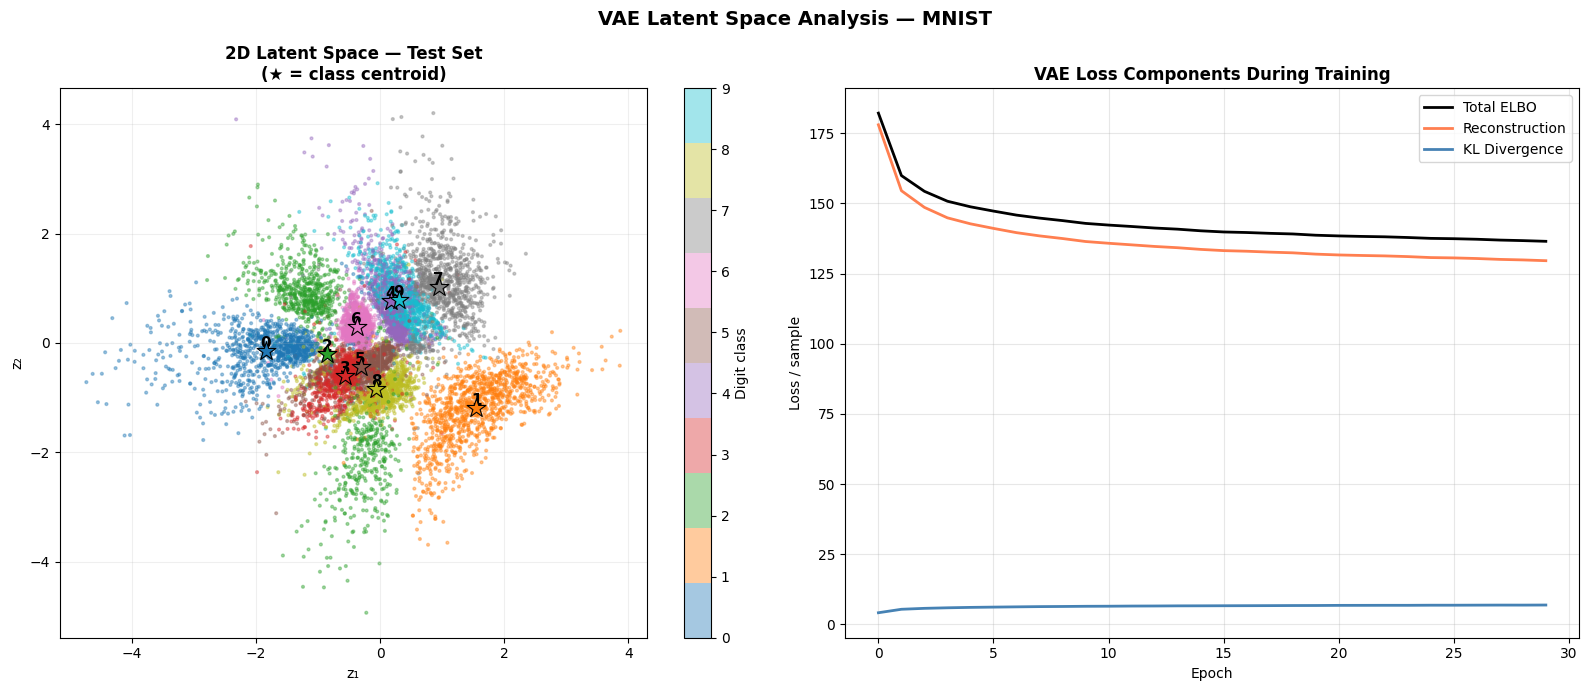

In [7]:
# Encode entire test set and collect latent codes
vae2d.eval()
all_mu, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        mu, _ = vae2d.encoder(imgs.to(device))
        all_mu.append(mu.cpu().numpy())
        all_labels.extend(labels.numpy())
all_mu     = np.concatenate(all_mu)
all_labels = np.array(all_labels)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 2D latent scatter
cmap    = plt.get_cmap('tab10')
scatter = axes[0].scatter(all_mu[:, 0], all_mu[:, 1],
                           c=all_labels, cmap='tab10', alpha=0.4, s=4)
plt.colorbar(scatter, ax=axes[0], label='Digit class')
# Add class centroids
for cls in range(10):
    mask = all_labels == cls
    cx, cy = all_mu[mask, 0].mean(), all_mu[mask, 1].mean()
    axes[0].scatter(cx, cy, c=[cmap(cls/10)], s=200, marker='*',
                    edgecolors='black', linewidth=0.8, zorder=5)
    axes[0].annotate(str(cls), (cx, cy), fontsize=11, fontweight='bold',
                     ha='center', va='bottom')
axes[0].set_title('2D Latent Space — Test Set\n(★ = class centroid)', fontweight='bold')
axes[0].set_xlabel('z₁'); axes[0].set_ylabel('z₂')
axes[0].grid(True, alpha=0.2)

# Training loss breakdown
axes[1].plot(history['total'], label='Total ELBO',       color='black',     linewidth=2)
axes[1].plot(history['recon'], label='Reconstruction',   color='coral',     linewidth=2)
axes[1].plot(history['kl'],    label='KL Divergence',    color='steelblue', linewidth=2)
axes[1].set_title('VAE Loss Components During Training', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss / sample')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('VAE Latent Space Analysis — MNIST', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('lab9_latent_space.png', dpi=150, bbox_inches='tight')
plt.show()

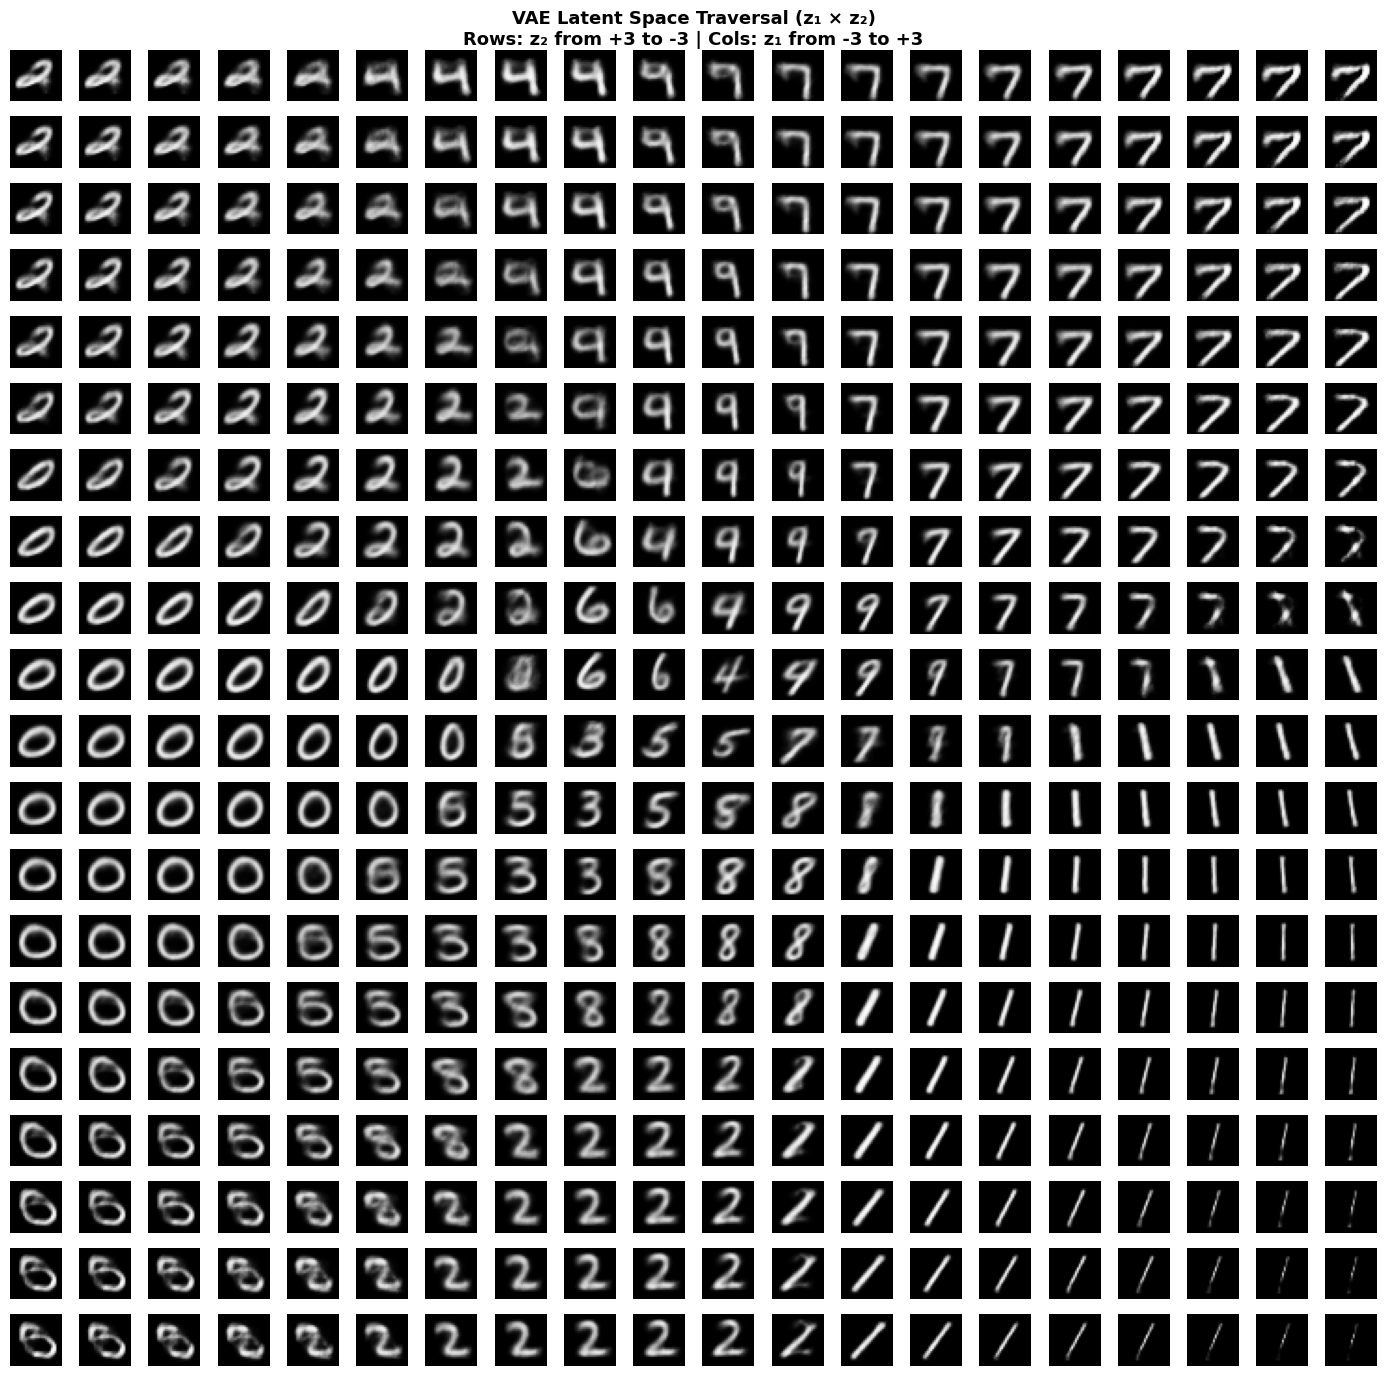

Latent traversal saved.


In [8]:
# Latent space traversal grid
n     = 20
grid_range = 3.0
z1s   = np.linspace(-grid_range, grid_range, n)
z2s   = np.linspace(-grid_range, grid_range, n)[::-1]

fig, axes = plt.subplots(n, n, figsize=(14, 14))
vae2d.eval()
with torch.no_grad():
    for i, z2 in enumerate(z2s):
        for j, z1 in enumerate(z1s):
            z   = torch.tensor([[z1, z2]], dtype=torch.float).to(device)
            img = vae2d.decoder(z).squeeze().cpu().numpy()
            axes[i, j].imshow(img, cmap='gray', vmin=0, vmax=1)
            axes[i, j].axis('off')

plt.suptitle('VAE Latent Space Traversal (z₁ × z₂)\nRows: z₂ from +3 to -3 | Cols: z₁ from -3 to +3',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('lab9_latent_traversal.png', dpi=120, bbox_inches='tight')
plt.show()
print('Latent traversal saved.')

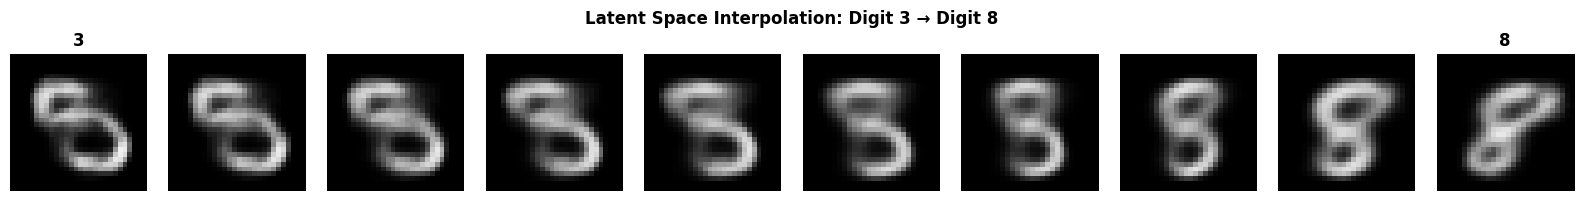

In [9]:
# Interpolation between two digit classes
def get_class_sample(digit_class, n=1):
    for imgs, labels in test_loader:
        mask = labels == digit_class
        if mask.sum() >= n:
            return imgs[mask][:n].to(device)

vae2d.eval()
with torch.no_grad():
    img_a = get_class_sample(3)  # digit 3
    img_b = get_class_sample(8)  # digit 8
    mu_a, _ = vae2d.encoder(img_a)
    mu_b, _ = vae2d.encoder(img_b)

    steps = 10
    interps = []
    for alpha in np.linspace(0, 1, steps):
        z_interp = (1 - alpha) * mu_a + alpha * mu_b
        interps.append(vae2d.decoder(z_interp).cpu().squeeze().numpy())

fig, axes = plt.subplots(1, steps, figsize=(16, 2))
for ax, img in zip(axes, interps):
    ax.imshow(img, cmap='gray', vmin=0, vmax=1); ax.axis('off')
axes[0].set_title('3', fontsize=12, fontweight='bold')
axes[-1].set_title('8', fontsize=12, fontweight='bold')
plt.suptitle('Latent Space Interpolation: Digit 3 → Digit 8', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('lab9_interpolation.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Interpretation of Latent Variables

### What the VAE learns
Each point in the 2D latent space represents a **compressed encoding** of an image. The VAE is forced (via KL loss) to organise this space so it resembles N(0,1) — a smooth, continuous Gaussian.

### Why the latent space has structure
Even though the KL term pushes all encodings toward N(0,1), the reconstruction loss forces different classes to occupy **different regions** — otherwise the decoder couldn't tell them apart. The result is a structured, **class-separated manifold**.

### What each axis encodes (2D VAE)
In a 2D latent space, the two dimensions typically learn continuous factors of variation:
- One axis may capture **stroke thickness** or **roundness**
- Another may capture **orientation** or **digit style**
- Digits with similar shapes (3/8, 4/9, 1/7) often cluster nearby

### KL vs Reconstruction trade-off
| β value | Effect |
|---------|--------|
| β = 0   | Regular autoencoder — sharp images, no latent structure |
| β = 1   | Standard VAE — good balance of quality and structure |
| β > 1   | β-VAE — more disentangled axes, but blurrier images |

### Why interpolation works
Because the KL term forces the latent space to be **continuous and smooth**, any point between two encodings also decodes to a valid image. This is the key difference from a standard autoencoder — GANs and VAEs both allow sampling and interpolation; autoencoders do not.